In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置绘图风格
plt.style.use('seaborn-paper')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 问题一模型搭建
class BatteryConfig:
    """
    电池物理参数配置类 
    """
    def __init__(self, soh=1.0, env_temp=25.0):
        self.Q_rated_mAh = 4500.0
        # 这里是常用手机电池电量，单位是毫安 可以根据自己的手机情况或者常见机型来调整
        self.Q_rated_Ah = self.Q_rated_mAh / 1000.0
        self.V_cutoff = 3.0
        self.V_nom = 3.85
        self.soh = soh
        self.Q_actual = self.Q_rated_Ah * self.soh
        
        # 内阻模型
        self.R_internal_base = 0.040 * (1 + 2.0 * (1 - self.soh)) 
        self.R_polarization = 0.010
        self.C_polarization = 500.0
        
        # 热力学参数
        self.mass = 0.20
        self.Cp = 900.0
        self.h_conv = 8.0
        self.area = 0.02
        self.T_amb = env_temp

    def get_ocv(self, soc):
        # 经验 OCV 曲线
        return 3.0 + 1.2 * soc - 0.6 * (soc**2) + 0.8 * (soc**3) - 0.1 * (soc**4)

    def get_resistance(self, soc, temp_c):
        # 混合内阻模型 
        temp_k = temp_c + 273.15
        ref_k = 25.0 + 273.15
        beta = 2000.0 
        temp_factor = np.exp(beta * (1/temp_k - 1/ref_k))
        soc_factor = 1.0 + 0.5 * np.exp(-10 * soc)
        return (self.R_internal_base + self.R_polarization) * temp_factor * soc_factor

class BatterySimulator:
    def __init__(self, config):
        self.cfg = config
        self.dt = 1.0 # 步长 1s

    def generate_user_profile(self, duration_hours=48, intensity_factor=1.0):
        """
        :param intensity_factor: 负载强度系数 (1.0=正常, >1.0=高功耗, <1.0=省电)
        """
        steps = int(duration_hours * 3600 / self.dt)
        # 基础功率状态 (W) * 强度系数
        states_power = np.array([0.1, 1.5, 3.0, 6.0]) * intensity_factor
        
        transition_matrix = [
            [0.95, 0.04, 0.01, 0.00], # Sleep
            [0.10, 0.80, 0.08, 0.02], # Light
            [0.05, 0.15, 0.75, 0.05], # Media
            [0.01, 0.10, 0.20, 0.69]  # Heavy
        ]
        
        power_profile = np.zeros(steps)
        current_state = 1
        
        seg_len = 60 # 每分钟切换一次状态
        # 这里是模拟用户切换手机使用场景的频率，单位为秒，可在60~300范围内调整
        
        n_segments = steps // seg_len
        
        for i in range(n_segments):
            base = states_power[current_state]
            noise = np.random.normal(0, 0.1 * base, seg_len)
            power_profile[i*seg_len : (i+1)*seg_len] = np.maximum(0.01, base + noise)
            current_state = np.random.choice([0, 1, 2, 3], p=transition_matrix[current_state])
            
        return power_profile

    def solve_current(self, P_load, V_ocv, V_p, R_total):
        # 解方程: I * (V_ocv - V_p - I*R) = P
        V_eff = V_ocv - V_p
        delta = V_eff**2 - 4 * R_total * P_load
        if delta < 0: return None
        return (V_eff - np.sqrt(delta)) / (2 * R_total)

    def run_simulation(self, initial_soc=1.0, power_intensity=1.0):
        """
        :param initial_soc: 初始电量 (0.0 - 1.0)
        :param power_intensity: 功耗强度系数
        """
        soc = initial_soc
        V_p = 0.0
        T = self.cfg.T_amb
        
        # 仅在需要时生成负载
        power_trace = self.generate_user_profile(duration_hours=24, intensity_factor=power_intensity)
        steps = len(power_trace)
        
        reason = "Time Limit"
        duration_hours = 0.0
        
        for t in range(steps):
            P_load = power_trace[t]
            R_total = self.cfg.get_resistance(soc, T)
            V_ocv = self.cfg.get_ocv(soc)
            I = self.solve_current(P_load, V_ocv, V_p, R_total)
            
            if I is None: 
                reason = "Voltage Collapse"
                duration_hours = t / 3600.0
                break
            
            V_term = V_ocv - V_p - I * R_total
            
            # 截止判定
            if soc <= 0.0:
                reason = "SOC Depleted"
                duration_hours = t / 3600.0
                break
            if V_term <= self.cfg.V_cutoff:
                reason = "Low Voltage"
                duration_hours = t / 3600.0
                break
                
            # 欧拉积分
            d_soc = -I / (self.cfg.Q_actual * 3600.0)
            d_vp = (I/self.cfg.C_polarization) - (V_p/(self.cfg.R_polarization*self.cfg.C_polarization))
            d_temp = (I**2*R_total - self.cfg.h_conv*self.cfg.area*(T-self.cfg.T_amb)) / (self.cfg.mass * self.cfg.Cp)
            
            soc += d_soc * self.dt
            V_p += d_vp * self.dt
            T += d_temp * self.dt
            
        return duration_hours, reason

print("仿真模型已加载。")

仿真模型已加载。


正在执行 OAT (One-at-a-Time) 灵敏度分析...
  正在计算基准 TTE (Baseline)...
  基准 TTE = 14.7045 hours
  分析参数: Battery Capacity ...
  分析参数: Internal Resistance ...
  分析参数: Heat Transfer Coeff ...
  分析参数: Thermal Mass ($m$) ...
  分析参数: Cutoff Voltage ...
  分析参数: Polarization Res ...


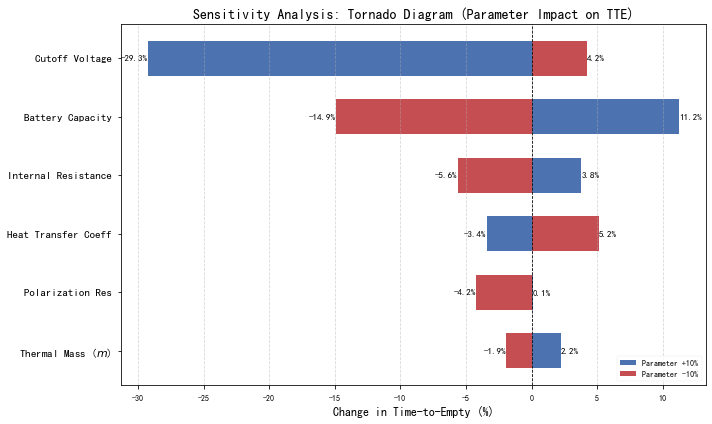


灵敏度数据汇总:
             Parameter  Low_Change_%  High_Change_%      Range
3   Thermal Mass ($m$)     -1.909002       2.219848   4.128850
5     Polarization Res     -4.213858       0.080852   4.294710
2  Heat Transfer Coeff      5.163778      -3.422148   8.585926
1  Internal Resistance     -5.611393       3.800435   9.411828
0     Battery Capacity    -14.931035      11.245739  26.176774
4       Cutoff Voltage      4.249089     -29.261156  33.510245


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


plt.style.use('seaborn-paper')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

def run_tornado_analysis():
    print("正在执行 OAT (One-at-a-Time) 灵敏度分析...")
    
    # 1. 定义待分析的参数及其基准值 (Baseline Values)
    # 这些是 BatteryConfig 中的内部参数
    # 格式: 'Parameter Name': {'attr': '属性名', 'base': 基准值, 'label': '图表标签'}
    param_map = {
        'Capacity':    {'attr': 'Q_rated_mAh',     'base': 4500.0, 'label': 'Battery Capacity'},
        'Resistance':  {'attr': 'R_internal_base', 'base': 0.040,  'label': 'Internal Resistance'},
        'HeatTransfer':{'attr': 'h_conv',          'base': 8.0,    'label': 'Heat Transfer Coeff'},
        'ThermalMass': {'attr': 'mass',            'base': 0.20,   'label': 'Thermal Mass ($m$)'},
        'CutoffVolt':  {'attr': 'V_cutoff',        'base': 3.0,    'label': 'Cutoff Voltage'},
        'Polarization':{'attr': 'R_polarization',  'base': 0.010,  'label': 'Polarization Res'}
    }
    
    # 2. 运行基准仿真 (Baseline Simulation)
    # 使用标准配置: SOH=1.0, Temp=25, SOC=1.0, Intensity=1.0
    base_cfg = BatteryConfig(soh=1.0, env_temp=25.0)
    base_sim = BatterySimulator(base_cfg)
    # 使用固定的随机种子或较长的仿真时间来平滑随机性
    # 消除随机负载噪声
    def get_stable_tte(cfg, n_avg=10):
        total_tte = 0
        sim = BatterySimulator(cfg)
        for _ in range(n_avg):
            tte, _ = sim.run_simulation(initial_soc=1.0, power_intensity=1.0)
            total_tte += tte
        return total_tte / n_avg

    print("  正在计算基准 TTE (Baseline)...")
    base_tte = get_stable_tte(base_cfg, n_avg=20) # 跑20次取平均
    print(f"  基准 TTE = {base_tte:.4f} hours")
    
    results = []
    
    # 3. 循环扰动每个参数
    for key, info in param_map.items():
        print(f"  分析参数: {info['label']} ...")
        
        #  情况 A:参数增加 10% (+10%) 
        high_val = info['base'] * 1.10
        # 动态修改 Config 属性
        cfg_high = BatteryConfig(soh=1.0, env_temp=25.0)
        setattr(cfg_high, info['attr'], high_val) 
        # 特殊处理: 如果修改了容量，需要同步更新 Q_actualA
        if info['attr'] == 'Q_rated_mAh':
            cfg_high.Q_rated_Ah = high_val / 1000.0
            cfg_high.Q_actual = cfg_high.Q_rated_Ah * cfg_high.soh
            
        tte_high = get_stable_tte(cfg_high, n_avg=20)
        change_high_pct = (tte_high - base_tte) / base_tte * 100
        
        # 情况 B: 参数减少 10% (-10%) 
        low_val = info['base'] * 0.90
        cfg_low = BatteryConfig(soh=1.0, env_temp=25.0)
        setattr(cfg_low, info['attr'], low_val)
        if info['attr'] == 'Q_rated_mAh':
            cfg_low.Q_rated_Ah = low_val / 1000.0
            cfg_low.Q_actual = cfg_low.Q_rated_Ah * cfg_low.soh
            
        tte_low = get_stable_tte(cfg_low, n_avg=20)
        change_low_pct = (tte_low - base_tte) / base_tte * 100
        
 
        results.append({
            'Parameter': info['label'],
            'Low_Change_%': change_low_pct,   # 参数变小导致的 TTE 变化率
            'High_Change_%': change_high_pct, # 参数变大导致的 TTE 变化率
            'Range': abs(change_high_pct - change_low_pct) # 敏感度幅度
        })
        
    # 4. 数据整理与排序
    df_res = pd.DataFrame(results)
    # 按敏感度幅度降序排列
    df_res = df_res.sort_values('Range', ascending=True) 
    
    # 5. 绘制龙卷风图 
    plt.figure(figsize=(10, 6))
    
    # 绘制条形
    y_pos = np.arange(len(df_res))
    
    # High Value Bars (参数增加 10%)
   

    plt.barh(y_pos, df_res['High_Change_%'], align='center', height=0.6, color='#4c72b0', label='Parameter +10%')
    plt.barh(y_pos, df_res['Low_Change_%'], align='center', height=0.6, color='#c44e52', label='Parameter -10%')
    # 修改color变量内容 如：blue、pink、red、yellow、green、purple、gold等
    

    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    

    plt.yticks(y_pos, df_res['Parameter'], fontsize=11)
    plt.xlabel('Change in Time-to-Empty (%)', fontsize=12)
    plt.title('Sensitivity Analysis: Tornado Diagram (Parameter Impact on TTE)', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    
    for i, (idx, row) in enumerate(df_res.iterrows()):
        # 标注 High 值
        plt.text(row['High_Change_%'], i, f"{row['High_Change_%']:.1f}%", 
                 va='center', ha='left' if row['High_Change_%'] > 0 else 'right', fontsize=9)
        # 标注 Low 值
        plt.text(row['Low_Change_%'], i, f"{row['Low_Change_%']:.1f}%", 
                 va='center', ha='right' if row['Low_Change_%'] < 0 else 'left', fontsize=9)
        
    plt.tight_layout()
    plt.show()
    
    return df_res

# 执行灵敏度分析
df_sensitivity = run_tornado_analysis()
print("\n灵敏度数据汇总:")
print(df_sensitivity)

正在执行全局灵敏度分析 (GSA) - 基于随机森林代理模型...
采样方法: Latin Hypercube Sampling (LHS), 样本量: 300
开始仿真 
训练随机森林回归模型
代理模型 R^2 分数: 0.8730 (越高代表模型越能解释数据)


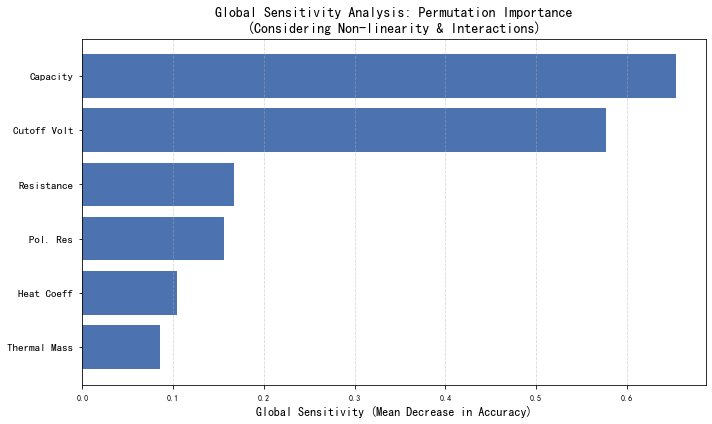


全局灵敏度重要性排序:
      Parameter  Importance_Mean  Importance_Std
5      Capacity         0.654220        0.053838
4   Cutoff Volt         0.577282        0.064112
3    Resistance         0.167351        0.015576
2      Pol. Res         0.156602        0.011413
1    Heat Coeff         0.104317        0.007760
0  Thermal Mass         0.085709        0.004380


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import qmc 
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split


plt.style.use('seaborn-paper')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

def run_global_sensitivity_analysis(n_samples=500):
    print(f"正在执行全局灵敏度分析 (GSA) - 基于随机森林代理模型...")
    print(f"采样方法: Latin Hypercube Sampling (LHS), 样本量: {n_samples}")
    
    # 1. 定义参数范围 

    problem = {
        'names': ['Capacity', 'Resistance', 'Heat Coeff', 
                  'Thermal Mass', 'Cutoff Volt', 'Pol. Res'],
        'bounds': [
            [4500 * 0.8, 4500 * 1.2], # Capacity: +/- 20%
            [0.04 * 0.7, 0.04 * 1.5], # Resistance: -30% ~ +50% (模拟老化)
            [5.0, 15.0],              # h: 5 ~ 15 (较大范围)
            [0.15, 0.25],             # mass: +/-
            [2.8, 3.2],               # Cutoff: 2.8V ~ 3.2V
            [0.005, 0.020]            # Rp: range
        ]
    }
    
    # 2. 拉丁超立方采样 (LHS)
    sampler = qmc.LatinHypercube(d=len(problem['names']), seed=42)
    sample_norm = sampler.random(n=n_samples)
    
    # 归一化映射范围
    l_bounds = np.array([b[0] for b in problem['bounds']])
    u_bounds = np.array([b[1] for b in problem['bounds']])
    samples_real = qmc.scale(sample_norm, l_bounds, u_bounds)
    
    X_df = pd.DataFrame(samples_real, columns=problem['names'])
    
    # 3. 批量运行仿真 
    y_tte = []
    

    print("开始仿真 ")
    
    # 内部重新定义 Config 和 Simulator 

    for i in range(n_samples):
        # 从样本中提取参数
        # 顺序: Q, R0, h, m, Vcut, Rp
        row = samples_real[i]
        
        cfg = BatteryConfig(soh=1.0, env_temp=25.0) # 基础环境
        # 覆盖参数
        cfg.Q_rated_mAh = row[0]
        cfg.Q_rated_Ah = row[0] / 1000.0
        cfg.Q_actual = cfg.Q_rated_Ah # 假设SOH=1的基础容量变化
        cfg.R_internal_base = row[1]
        cfg.h_conv = row[2]
        cfg.mass = row[3]
        cfg.V_cutoff = row[4]
        cfg.R_polarization = row[5]
        
        sim = BatterySimulator(cfg)
 
        tte, reason = sim.run_simulation(initial_soc=1.0, power_intensity=1.0)
        y_tte.append(tte)
        
    y = np.array(y_tte)
    
    # 4. 构建代理模型 
    print("训练随机森林回归模型")
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_df, y)
    print(f"代理模型 R^2 分数: {rf.score(X_df, y):.4f} (越高代表模型越能解释数据)")
    
    # 5. 计算排列重要性 
  
    result = permutation_importance(rf, X_df, y, n_repeats=10, random_state=42, n_jobs=1)
    
    # 整理结果
    sorted_idx = result.importances_mean.argsort()
    
    # 6. 绘图
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx], color='#4c72b0', align='center')
     # 修改color变量内容 如：blue、pink、red、yellow、green、purple、gold等
    plt.yticks(range(len(sorted_idx)), [problem['names'][i] for i in sorted_idx], fontsize=11)
    plt.xlabel('Global Sensitivity (Mean Decrease in Accuracy)', fontsize=12)
    plt.title('Global Sensitivity Analysis: Permutation Importance\n(Considering Non-linearity & Interactions)', fontsize=14)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    

    importance_df = pd.DataFrame({
        'Parameter': [problem['names'][i] for i in sorted_idx],
        'Importance_Mean': result.importances_mean[sorted_idx],
        'Importance_Std': result.importances_std[sorted_idx]
    }).sort_values('Importance_Mean', ascending=False)
    
    return importance_df

# 执行全局灵敏度分析

df_global_sensitivity = run_global_sensitivity_analysis(n_samples=300)
print("\n全局灵敏度重要性排序:")
print(df_global_sensitivity)